# Dawn to Dusk — Infographic
___
**Muneeb Mennad**\
**202175220**\
12/04/2026

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.image as mpimg

from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import to_rgb

## Design system

Shared palette, typography, and matplotlib defaults. Everything else in the notebook pulls from here.

In [2]:
# ─── palette ──────────────────────────────────────────────────────────────────

# BG          = "#0a0e1a"  # deep night sky
BG          = "#000000"  # deep night sky
TEXT        = "#f4ecd8"  # parchment off-white
TEXT_MUTED  = "#8a8578"
GRID        = "#1e2332"
PANEL       = "#11162a"

# sun-to-moon spectrum (24h progression)
PREDAWN  = "#3d2c5c"
DAWN     = "#e85d24"
MORNING  = "#f2a623"
MIDDAY   = "#fcde5a"
AFTNOON  = "#e8a23c"
DUSK     = "#8b5cf6"
NIGHT    = "#3b5998"
DEEPNITE = "#1e2a4a"

# 24-hour gradient — walks the sun-to-moon spectrum by hour
def hour_gradient(n=24):
    stops = [
        (0,  DEEPNITE),
        (4,  PREDAWN),
        (6,  DAWN),
        (9,  MORNING),
        (12, MIDDAY),
        (15, AFTNOON),
        (18, DUSK),
        (20, NIGHT),
        (23, DEEPNITE),
    ]
    positions = [s[0] / 23 for s in stops]
    colors    = [s[1] for s in stops]
    cmap = LinearSegmentedColormap.from_list("sun_moon", list(zip(positions, colors)), N=256)
    return [cmap(h / 23) for h in range(n)]

# ─── typography ───────────────────────────────────────────────────────────────

def _pick_font():
    """prefer JetBrains Mono, fall back to DejaVu Sans Mono"""
    available = {f.name for f in font_manager.fontManager.ttflist}
    for candidate in ("JetBrains Mono", "JetBrainsMono", "DejaVu Sans Mono"):
        if candidate in available:
            return candidate
    return "monospace"

FONT = _pick_font()

# ─── matplotlib defaults ──────────────────────────────────────────────────────

mpl.rcParams.update({
    "figure.facecolor":   BG,
    "axes.facecolor":     BG,
    "savefig.facecolor":  BG,
    "savefig.edgecolor":  BG,

    "font.family":        FONT,
    "font.size":          14,

    "text.color":         TEXT,
    "axes.labelcolor":    TEXT,
    "axes.titlecolor":    TEXT,
    "xtick.color":        TEXT_MUTED,
    "ytick.color":        TEXT_MUTED,

    "axes.edgecolor":     GRID,
    "axes.linewidth":     0.6,
    "axes.grid":          False,

    "grid.color":         GRID,
    "grid.linewidth":     0.5,
    "grid.alpha":         0.6,

    "axes.spines.top":    False,
    "axes.spines.right":  False,

    "xtick.major.size":   3,
    "ytick.major.size":   3,
    "xtick.major.width":  0.5,
    "ytick.major.width":  0.5,

    "legend.facecolor":   BG,
    "legend.edgecolor":   GRID,
    "legend.labelcolor":  TEXT,
    "legend.fontsize":    12,
})

print(f"font: {FONT}")

font: DejaVu Sans Mono


## Load data

In [3]:
df = pd.read_csv("birds.csv", engine="python", on_bad_lines="skip")
df["OBSERVATION DATE"] = pd.to_datetime(df["OBSERVATION DATE"])
df["month"] = df["OBSERVATION DATE"].dt.month
df["hour"]  = pd.to_datetime(df["TIME OBSERVATIONS STARTED"], format="%H:%M:%S", errors="coerce").dt.hour

print(f"{len(df):,} observations")
print(f"{df['COMMON NAME'].nunique()} species")
print(f"{df['COUNTY'].nunique()} counties")

202,089 observations
295 species
11 counties


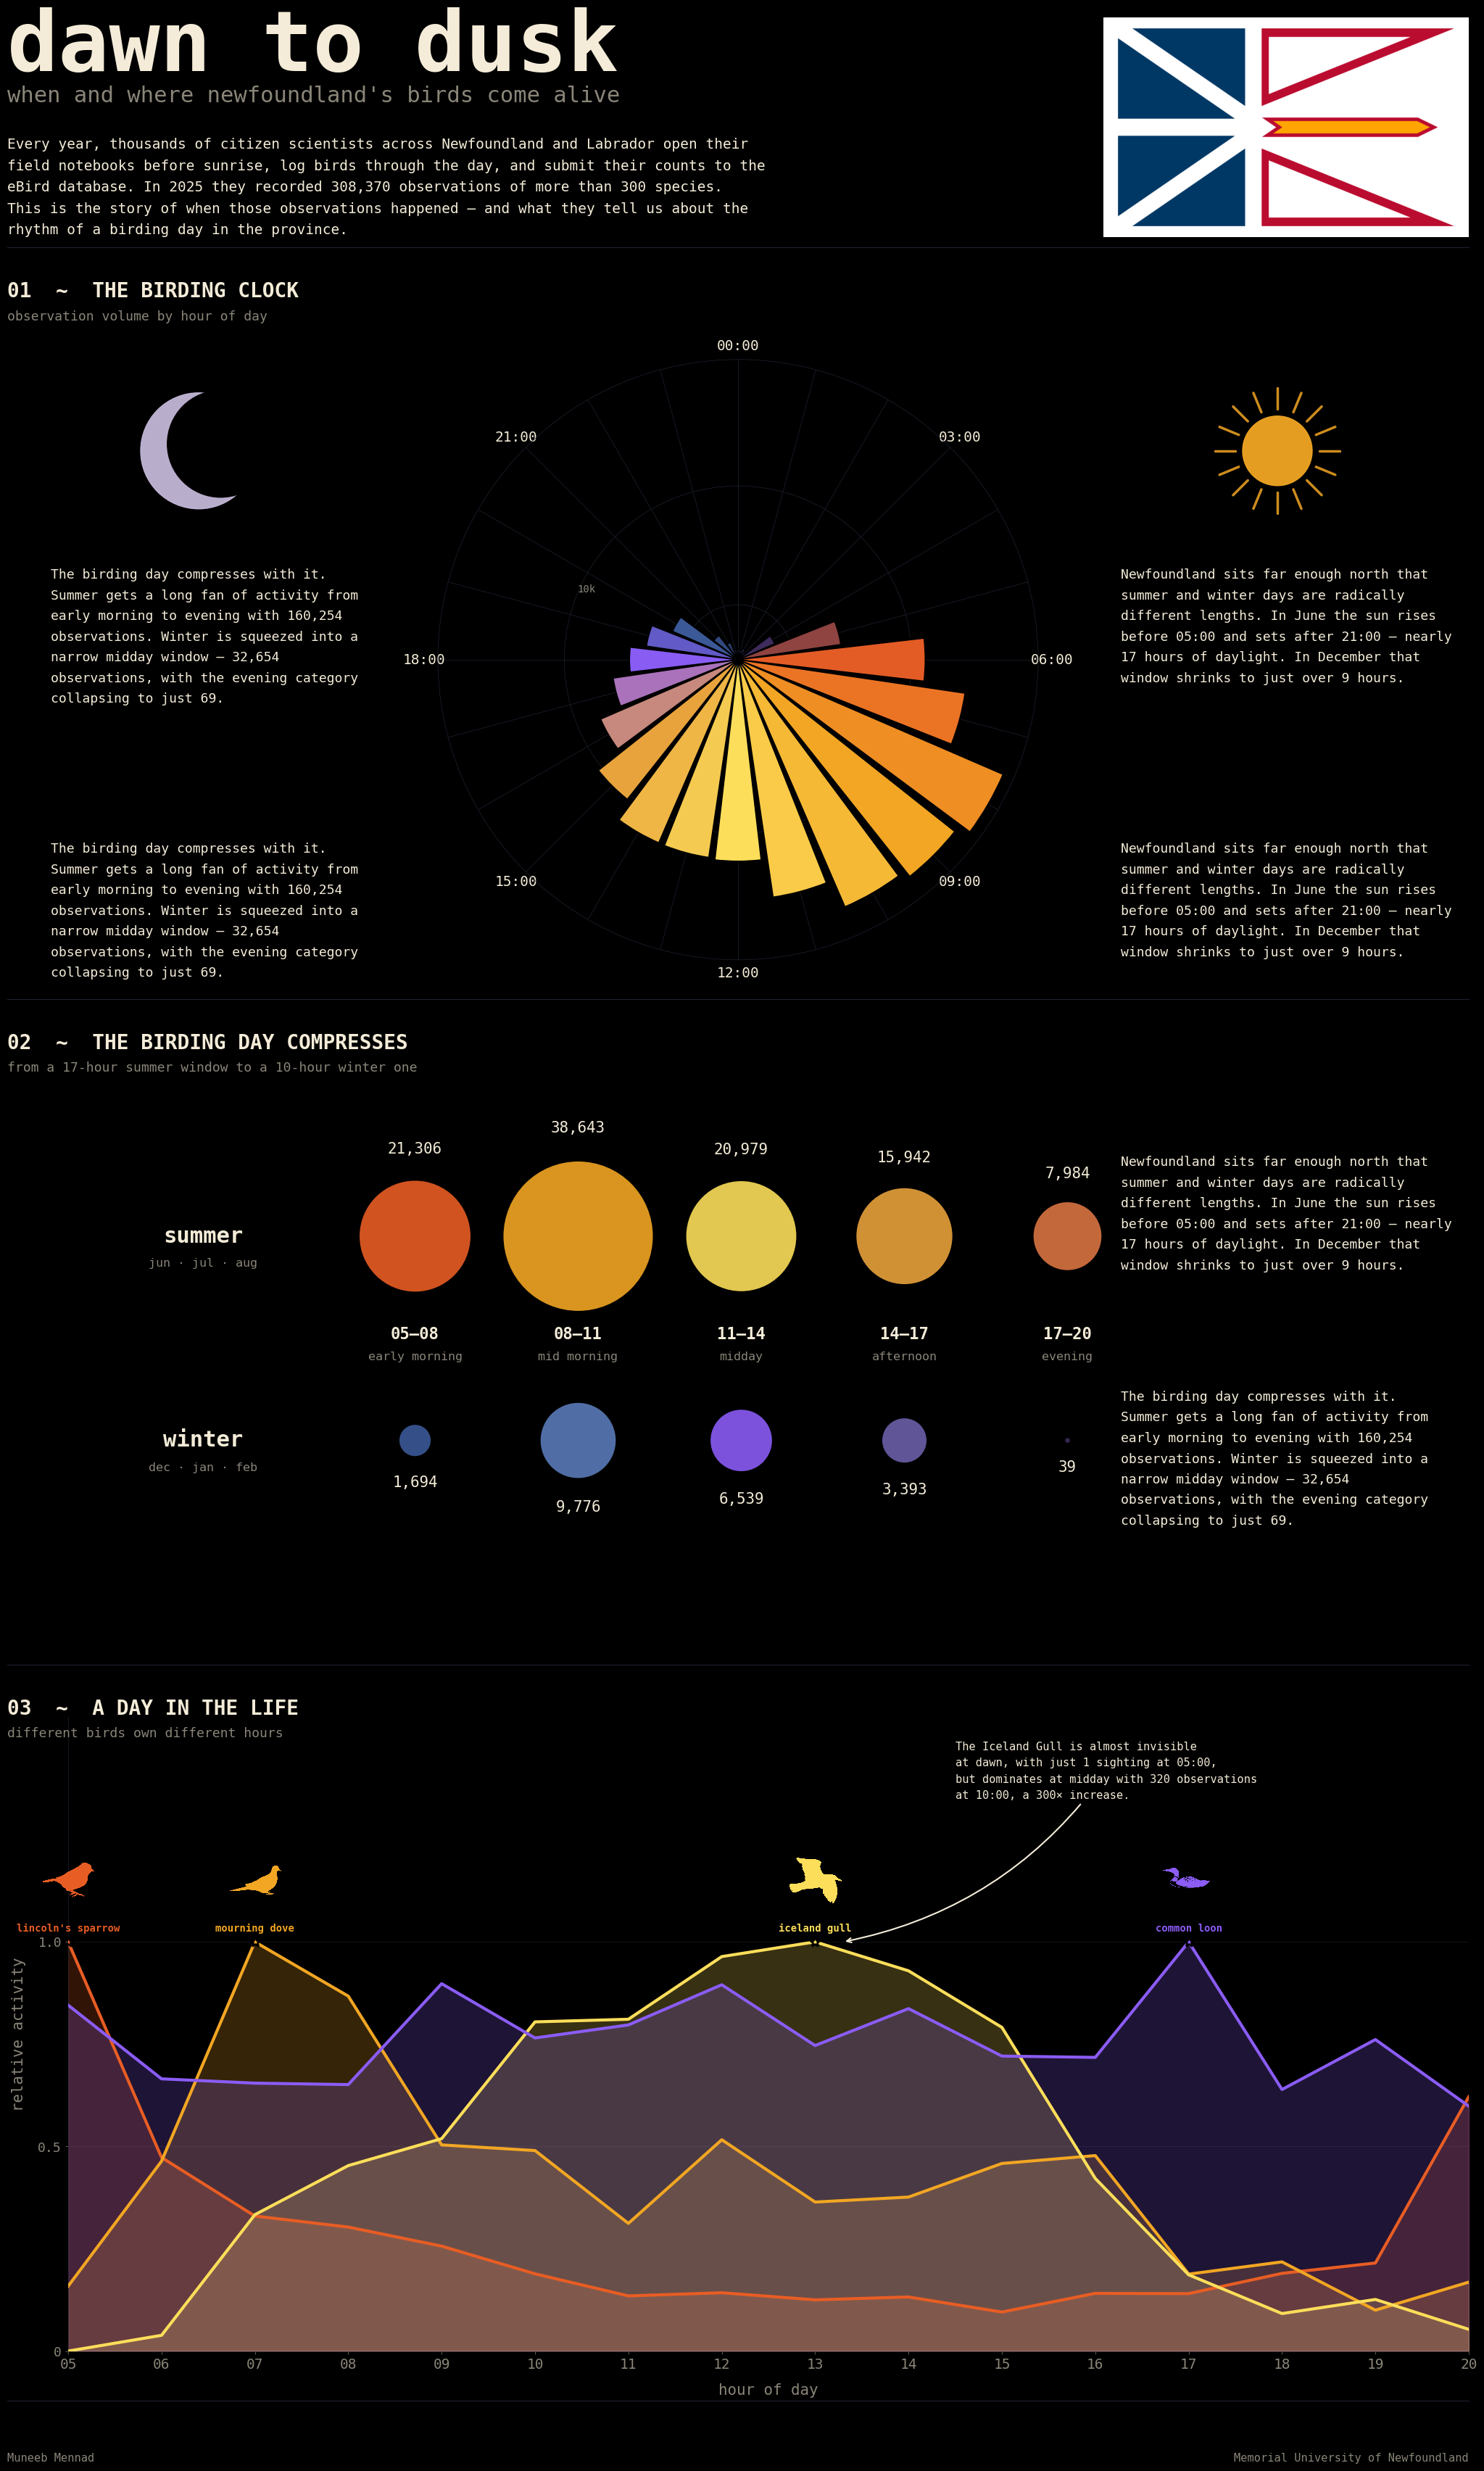

In [28]:
fig = plt.figure(figsize=(24, 36), facecolor=BG)

# margins
LEFT  = 0.08
RIGHT = 0.92
WIDTH = RIGHT - LEFT  # 0.84

Y_TITLE_TOP    = 0.965
Y_INTRO_BOTTOM = 0.885
DIVIDER_1      = 0.873

# 1 - clock
Y_S1_LABEL    = 0.860
Y_S1_AX_TOP   = 0.830
Y_S1_AX_BOT   = 0.600
Y_S1_PROSE_SUN= 0.650
DIVIDER_2     = 0.585

# 2 - svw
Y_S2_LABEL    = 0.572
Y_S2_AX_TOP   = 0.540
Y_S2_AX_BOT   = 0.390
Y_S2_PROSE    = 0.365
DIVIDER_3     = 0.330

# 3 - dil
Y_S3_LABEL    = 0.317
Y_S3_AX_TOP   = 0.310
Y_S3_AX_BOT   = 0.067
Y_S3_PROSE    = 0.075
DIVIDER_4     = 0.048

Y_FOOTER      = 0.028


# header

fig.text(LEFT, Y_TITLE_TOP, "dawn to dusk",
         ha="left", va="top",
         color=TEXT, fontsize=84, fontweight="bold", family=FONT)
fig.text(LEFT, Y_TITLE_TOP - 0.030, "when and where newfoundland's birds come alive",
         ha="left", va="top",
         color=TEXT_MUTED, fontsize=22, family=FONT)

intro = (
    "Every year, thousands of citizen scientists across Newfoundland and Labrador open their\n"
    "field notebooks before sunrise, log birds through the day, and submit their counts to the\n"
    "eBird database. In 2025 they recorded 308,370 observations of more than 300 species.\n"
    "This is the story of when those observations happened — and what they tell us about the\n"
    "rhythm of a birding day in the province."
)
fig.text(LEFT, Y_INTRO_BOTTOM + 0.030, intro,
         ha="left", va="top",
         color=TEXT, fontsize=14, family=FONT, linespacing=1.7)

flag_img = plt.imread("newfoundland-and-labrador-flag.png")
flag_ax = fig.add_axes([0.71, 0.873, RIGHT - 0.71, Y_TITLE_TOP - DIVIDER_1], facecolor=BG)
flag_ax.imshow(flag_img)
flag_ax.axis("off")

fig.add_artist(plt.Line2D([LEFT, RIGHT], [DIVIDER_1, DIVIDER_1],
                          color=GRID, linewidth=0.8))

# section 1

fig.text(LEFT, Y_S1_LABEL, "01  ~  THE BIRDING CLOCK",
         ha="left", va="top",
         color=TEXT, fontsize=20, fontweight="bold", family=FONT)
fig.text(LEFT, Y_S1_LABEL - 0.011, "observation volume by hour of day",
         ha="left", va="top",
         color=TEXT_MUTED, fontsize=13, family=FONT)

clock_w = 0.48
clock_x = LEFT + (WIDTH - clock_w) / 2
ax1 = fig.add_axes([clock_x, Y_S1_AX_BOT, clock_w, Y_S1_AX_TOP - Y_S1_AX_BOT],
                   projection="polar", facecolor=BG)

hourly = df.groupby("hour").size().reindex(range(24), fill_value=0)
angles = np.array([2 * np.pi * h / 24 for h in range(24)])
width  = 2 * np.pi / 24 * 0.88
colors = hour_gradient(24)
heights = np.sqrt(hourly.values)

ax1.bar(angles, heights, width=width, color=colors,
        edgecolor=BG, linewidth=1.2, align="center", zorder=3)
ax1.set_theta_zero_location("N")
ax1.set_theta_direction(-1)
ax1.set_xticks(angles)
ax1.set_xticklabels([f"{h:02d}:00" if h % 3 == 0 else "" for h in range(24)],
                    fontsize=14, color=TEXT)

ymax_true = int(hourly.max() * 1.08)
ax1.set_yticks([np.sqrt(v) for v in [1000, 10000, 40000]])
ax1.set_yticklabels(["1k", "10k", "40k"], fontsize=10, color=TEXT_MUTED)
ax1.set_ylim(0, np.sqrt(ymax_true))
ax1.set_rlabel_position(292)
ax1.grid(color=GRID, linewidth=0.5, alpha=1, zorder=1)
ax1.spines["polar"].set_color(GRID)
ax1.spines["polar"].set_linewidth(0.5)

# sund & moon
deco_size = 0.08
deco_y    = Y_S1_AX_BOT + (Y_S1_AX_TOP - Y_S1_AX_BOT) / 2 - deco_size / 2 + 0.08

moon_x = clock_x - deco_size - 0.03
moon_ax = fig.add_axes([moon_x, deco_y, deco_size, deco_size], facecolor=BG)
moon_ax.set_xlim(-1.2, 1.2)
moon_ax.set_ylim(-1.2, 1.2)
moon_ax.set_aspect("equal")
moon_ax.axis("off")

moon_color = "#c4b8d8"  # pale silvery moon
moon_ax.add_patch(plt.Circle((0, 0), 1.0, color=moon_color, alpha=0.95, zorder=2))
moon_ax.add_patch(plt.Circle((0.38, 0.12), 0.92, color=BG, zorder=3))

sun_x = clock_x + clock_w + 0.03
sun_ax = fig.add_axes([sun_x, deco_y, deco_size, deco_size], facecolor=BG)
sun_ax.set_xlim(-1.5, 1.5)
sun_ax.set_ylim(-1.5, 1.5)
sun_ax.set_aspect("equal")
sun_ax.axis("off")

sun_color = MORNING
sun_ax.add_patch(plt.Circle((0, 0), 0.75, color=sun_color, alpha=0.95, zorder=3))

# keep as 16
n_rays = 16
ray_inner = 0.9
ray_outer = 1.35
for k in range(n_rays):
    theta = 2 * np.pi * k / n_rays
    x1 = ray_inner * np.cos(theta)
    y1 = ray_inner * np.sin(theta)
    x2 = ray_outer * np.cos(theta)
    y2 = ray_outer * np.sin(theta)
    sun_ax.plot([x1, x2], [y1, y2],
                color=sun_color, linewidth=2.5,
                alpha=0.85, solid_capstyle="round", zorder=2)

prose1_sun_top = (
    "Newfoundland sits far enough north that\n"
    "summer and winter days are radically\n"
    "different lengths. In June the sun rises\n"
    "before 05:00 and sets after 21:00 — nearly\n"
    "17 hours of daylight. In December that\n"
    "window shrinks to just over 9 hours."
)
prose1_moon_top = (
    "The birding day compresses with it.\n"
    "Summer gets a long fan of activity from\n"
    "early morning to evening with 160,254\n"
    "observations. Winter is squeezed into a\n"
    "narrow midday window — 32,654\n"
    "observations, with the evening category\n"
    "collapsing to just 69."
)
prose1_sun_bot = (
    "Newfoundland sits far enough north that\n"
    "summer and winter days are radically\n"
    "different lengths. In June the sun rises\n"
    "before 05:00 and sets after 21:00 — nearly\n"
    "17 hours of daylight. In December that\n"
    "window shrinks to just over 9 hours."
)
prose1_moon_bot = (
    "The birding day compresses with it.\n"
    "Summer gets a long fan of activity from\n"
    "early morning to evening with 160,254\n"
    "observations. Winter is squeezed into a\n"
    "narrow midday window — 32,654\n"
    "observations, with the evening category\n"
    "collapsing to just 69."
)
fig.text(LEFT + 0.025, Y_S1_AX_TOP - 0.080, prose1_moon_top,
         ha="left", va="top",
         color=TEXT, fontsize=13, family=FONT, linespacing=1.75)
fig.text(0.72, Y_S1_AX_TOP - 0.080, prose1_sun_top,
         ha="left", va="top",
         color=TEXT, fontsize=13, family=FONT, linespacing=1.75)
fig.text(LEFT + 0.025, Y_S1_AX_BOT + 0.045, prose1_moon_bot,
         ha="left", va="top",
         color=TEXT, fontsize=13, family=FONT, linespacing=1.75)
fig.text(0.72, Y_S1_AX_BOT + 0.045, prose1_sun_bot,
         ha="left", va="top",
         color=TEXT, fontsize=13, family=FONT, linespacing=1.75)

fig.add_artist(plt.Line2D([LEFT, RIGHT], [DIVIDER_2, DIVIDER_2],
                          color=GRID, linewidth=0.8))

# 2nd block

fig.text(LEFT, Y_S2_LABEL, "02  ~  THE BIRDING DAY COMPRESSES",
         ha="left", va="top",
         color=TEXT, fontsize=20, fontweight="bold", family=FONT)
fig.text(LEFT, Y_S2_LABEL - 0.011, "from a 17-hour summer window to a 10-hour winter one",
         ha="left", va="top",
         color=TEXT_MUTED, fontsize=13, family=FONT)

CIRCLES_W = 0.675
ax2 = fig.add_axes([LEFT, Y_S2_AX_BOT - 0.010, CIRCLES_W, Y_S2_AX_TOP - Y_S2_AX_BOT],
                   facecolor=BG)

summer = df[df["month"].isin([6, 7, 8])]
winter = df[df["month"].isin([12, 1, 2])]

buckets = [
    ("early morning", "05–08", (5, 8)),
    ("mid morning",   "08–11", (8, 11)),
    ("midday",        "11–14", (11, 14)),
    ("afternoon",     "14–17", (14, 17)),
    ("evening",       "17–20", (17, 20)),
]

def bucket_count(df_season, lo, hi):
    return ((df_season["hour"] >= lo) & (df_season["hour"] < hi)).sum()

summer_counts = np.array([bucket_count(summer, lo, hi) for _, _, (lo, hi) in buckets])
winter_counts = np.array([bucket_count(winter, lo, hi) for _, _, (lo, hi) in buckets])

MAX_VAL  = max(summer_counts.max(), winter_counts.max())
MAX_SIZE = 22000

def sizes(arr):
    return MAX_SIZE * (arr / MAX_VAL)

summer_colors = [DAWN, MORNING, MIDDAY, AFTNOON, "#d97442"]
winter_colors = [NIGHT, "#5a7bb8", DUSK, "#6b5fa8", PREDAWN]

x_positions = np.arange(len(buckets))
Y_SUMMER = 1.2
Y_WINTER = -1.2

# circles
ax2.scatter(x_positions, [Y_SUMMER] * len(buckets),
            s=sizes(summer_counts), c=summer_colors,
            alpha=0.9, zorder=3, edgecolors="none")
ax2.scatter(x_positions, [Y_WINTER] * len(buckets),
            s=sizes(winter_counts), c=winter_colors,
            alpha=0.9, zorder=3, edgecolors="none")

# count labels + bucket titles
for i, (label, time_range, _) in enumerate(buckets):
    s_off = np.sqrt(sizes(summer_counts)[i]) / 150 + 0.2
    w_off = np.sqrt(sizes(winter_counts)[i]) / 150 + 0.2

    ax2.text(i, Y_SUMMER + s_off, f"{summer_counts[i]:,}",
             ha="center", va="bottom",
             color=TEXT, fontsize=15, family=FONT)
    ax2.text(i, Y_WINTER - w_off, f"{winter_counts[i]:,}",
             ha="center", va="top",
             color=TEXT, fontsize=15, family=FONT)
    ax2.text(i, 0.05, time_range,
             ha="center", va="center",
             color=TEXT, fontsize=16, fontweight="bold", family=FONT)
    ax2.text(i, -0.22, label,
             ha="center", va="center",
             color=TEXT_MUTED, fontsize=12, family=FONT)

# row labels (summer / winter)
ax2.text(-1.3, Y_SUMMER, "summer",
         ha="center", va="center",
         color=TEXT, fontsize=22, fontweight="bold", family=FONT)
ax2.text(-1.3, Y_SUMMER - 0.32, f"jun · jul · aug",
         ha="center", va="center",
         color=TEXT_MUTED, fontsize=12, family=FONT)
ax2.text(-1.3, Y_WINTER, "winter",
         ha="center", va="center",
         color=TEXT, fontsize=22, fontweight="bold", family=FONT)
ax2.text(-1.3, Y_WINTER - 0.32, f"dec · jan · feb",
         ha="center", va="center",
         color=TEXT_MUTED, fontsize=12, family=FONT)

ax2.set_xlim(-2.5, len(buckets) - 0.3)
ax2.set_ylim(-2.3, 2.3)
ax2.axis("off")

PROSE_X = 0.72

prose2_top = (
    "Newfoundland sits far enough north that\n"
    "summer and winter days are radically\n"
    "different lengths. In June the sun rises\n"
    "before 05:00 and sets after 21:00 — nearly\n"
    "17 hours of daylight. In December that\n"
    "window shrinks to just over 9 hours."
)
prose2_bot = (
    "The birding day compresses with it.\n"
    "Summer gets a long fan of activity from\n"
    "early morning to evening with 160,254\n"
    "observations. Winter is squeezed into a\n"
    "narrow midday window — 32,654\n"
    "observations, with the evening category\n"
    "collapsing to just 69."
)
fig.text(PROSE_X, Y_S2_AX_TOP - 0.015, prose2_top,
         ha="left", va="top",
         color=TEXT, fontsize=13, family=FONT, linespacing=1.75)
fig.text(PROSE_X, Y_S2_AX_TOP - 0.105, prose2_bot,
         ha="left", va="top",
         color=TEXT, fontsize=13, family=FONT, linespacing=1.75)

fig.add_artist(plt.Line2D([LEFT, RIGHT], [DIVIDER_3, DIVIDER_3],
                          color=GRID, linewidth=0.8))

# 3rd block

fig.text(LEFT, Y_S3_LABEL, "03  ~  A DAY IN THE LIFE",
         ha="left", va="top",
         color=TEXT, fontsize=20, fontweight="bold", family=FONT)
fig.text(LEFT, Y_S3_LABEL - 0.011, "different birds own different hours",
         ha="left", va="top",
         color=TEXT_MUTED, fontsize=13, family=FONT)

YLABEL_INSET = 0.035
ax3 = fig.add_axes([LEFT + YLABEL_INSET, Y_S3_AX_BOT, WIDTH - YLABEL_INSET, Y_S3_AX_TOP - Y_S3_AX_BOT],
                   facecolor=BG)


df3 = df[(df["hour"] >= 5) & (df["hour"] <= 20)]
hours_day = list(range(5, 21))
total_per_hour = df3.groupby("hour").size().reindex(hours_day, fill_value=0)

species_info = [
    ("Lincoln's Sparrow",       DAWN,    "lincoln.png"),
    ("Mourning Dove",           MORNING, "dove.png"),
    ("Iceland Gull",            MIDDAY,  "gull.png"),
    ("Common Loon",             DUSK,    "loon.png"),
]

for sp_name, color, img_path in species_info:
    sp_counts = df3[df3["COMMON NAME"] == sp_name].groupby("hour").size().reindex(hours_day, fill_value=0)
    rate = sp_counts / total_per_hour
    rel  = rate / rate.max()
    ax3.fill_between(hours_day, rel, alpha=0.22, color=color, zorder=2)
    ax3.plot(hours_day, rel, color=color, linewidth=3, zorder=3, label=sp_name.lower())
    peak_hr = int(rate.idxmax())
    raw = plt.imread(img_path)
    alpha = raw[:, :, 3:4]
    r, g, b = to_rgb(color)
    tinted = np.zeros_like(raw)
    tinted[:, :, 0] = r
    tinted[:, :, 1] = g
    tinted[:, :, 2] = b
    tinted[:, :, 3] = alpha[:, :, 0]
    imagebox = OffsetImage(tinted, zoom=0.05)
    ab = AnnotationBbox(imagebox, (peak_hr, 1.15),
                        frameon=False, zorder=5)
    ax3.add_artist(ab)
    ax3.plot([peak_hr], [1.0], marker="*", color=color, markersize=10, 
             markeredgecolor=BG, markeredgewidth=2, zorder=4)
    ax3.annotate(sp_name.lower(), (peak_hr, 1.02),
                 ha="center", va="bottom",
                 color=color, fontsize=10, fontweight="bold",
                 family=FONT)

# ── annotation callout ────────────────────────────────────────────
note_text = (
    "The Iceland Gull is almost invisible\n"
    "at dawn, with just 1 sighting at 05:00,\n"
    "but dominates at midday with 320 observations\n"
    "at 10:00, a 300× increase."
)

# position the text to the right of the gull's peak
ax3.annotate(
    note_text,
    xy=(13.3, 1.0),                    # arrow points to the peak
    xytext=(14.5, 1.35),             # text positioned to the right
    fontsize=11,
    color=TEXT,
    family=FONT,
    linespacing=1.6,
    arrowprops=dict(
        arrowstyle="->",
        lw=1.5,
        color=TEXT,
        connectionstyle="arc3,rad=-0.2",
    ),
)

ax3.set_xlim(5, 20)
ax3.set_ylim(0, 1.55)
ax3.set_xticks(range(5, 21))
ax3.set_xticklabels([f"{h:02d}" for h in range(5, 21)], color=TEXT_MUTED, fontsize=14)
ax3.set_yticks([0, 0.5, 1.0])
ax3.set_yticklabels(["0", "0.5", "1.0"], color=TEXT_MUTED, fontsize=13)
ax3.set_xlabel("hour of day", color=TEXT_MUTED, fontsize=15, labelpad=12)
ax3.set_ylabel("relative activity", color=TEXT_MUTED, fontsize=15, labelpad=12)
ax3.grid(axis="y", color=GRID, linewidth=0.5, alpha=0.7, zorder=1)
ax3.set_axisbelow(True)
for spine in ax3.spines.values():
    spine.set_color(GRID)
    spine.set_linewidth(0.5)

# footer

fig.add_artist(plt.Line2D([LEFT, RIGHT], [DIVIDER_4, DIVIDER_4],
                          color=GRID, linewidth=0.8))

fig.text(LEFT, Y_FOOTER,
         "Muneeb Mennad",
         ha="left", va="top",
         color=TEXT_MUTED, fontsize=11, family=FONT)
fig.text(RIGHT, Y_FOOTER,
         "Memorial University of Newfoundland",
         ha="right", va="top",
         color=TEXT_MUTED, fontsize=11, family=FONT)

plt.show()